## EDA (Análisis exploratorio de datos) Formulación de preguntas claves para su desarrollo

1. **¿Quién se enferma más?**
- Analizar la frecuencia de enfermedad según edad, sexo y condiciones preexistentes.
2. **¿Cuánto cuesta enfermarse?**  
- Explorar el costo promedio y total de los siniestros.
3. **¿Qué tan seguido?**  
- Medir la frecuencia de uso del seguro o número de reclamaciones.
4. **¿Dónde?**
- Identificar en qué ciudades se presentan más casos o mayores
5. **¿De qué?** 
- Determinar los diagnósticos o tipos de reclamación más comunes.

## Pasos  establecidos y ejecutados
- Paso 1: Resumen ejecutivo
- Paso 2: Pefil Demográfico
- Paso 3: Los que utilizan el seguro
- Paso 4: Distribución del costo
- Paso 5: Condiciones preexistentes
- Paso 6: Tipos de Reclamación 
- Paso 7: Matriz de correlaciones
- Paso 8: Heatmaps Cruzados
- Paso 9: Construcción de base final para modelado

## Librerias, renombramietno y  previsualización de la base de datos `df_modelo_para_tarifacion`

In [1]:
# Librerias requeridas para ejecutar el codigo
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


proyecto_root = Path.cwd().parent
ruta_csv = proyecto_root / "data" / "df_para_EDA.csv"

df_eda = pd.read_csv(ruta_csv)
print(df_eda.shape)
df_eda.head()

(260853, 32)


,Afiliado_Id,FechaNacimiento_dt,edad,grupo_edad,CIUDAD_NORM,Sexo_Cd_limpio,CANCER,DIABETES,ENF_CARDIACA,HIPERTENSION,...,rec_CONSULTAS,rec_EXAMENES MEDICOS,rec_HOSPITALIZACIONES COMPLEJAS,rec_HOSPITALIZACIONES SIMPLES,rec_LABORATORIO,rec_TRATAMIENTO DE CANCER,en_exposicion,en_siniestros,categoria_cobertura,sin_exposicion_match
0,921437,1968-04-30,57,46-60,MEDELLIN,F,0,0,0,0,...,0,1,0,0,0,0,1,1,Completo (Exp + Sin),0
1,60504878,2012-02-18,14,0-17,MEDELLIN,M,0,0,0,0,...,0,0,0,1,0,0,1,1,Completo (Exp + Sin),0
2,55074222,2014-10-23,11,0-17,MEDELLIN,F,0,0,0,0,...,0,4,1,1,0,0,1,1,Completo (Exp + Sin),0
3,23690690,1989-06-27,36,31-45,CARTAGENA,F,0,0,0,0,...,0,4,0,0,0,0,1,1,Completo (Exp + Sin),0
4,45506882,2009-06-30,16,0-17,CALI,M,0,0,0,0,...,0,1,0,1,0,0,1,1,Completo (Exp + Sin),0


In [2]:
# 1) Número total de variables
print("N° de variables:", len(df_eda.columns))

# 2) Lista completa de nombres
print(df_eda.columns.tolist())

# 3) Tabla ordenada de variables (más legible)
display(
    pd.DataFrame({
        "variable": df_eda.columns,
        "dtype": df_eda.dtypes.astype(str).values,
        "nulos": df_eda.isna().sum().values
    }).sort_values("variable").reset_index(drop=True)
)

N° de variables: 32
['Afiliado_Id', 'FechaNacimiento_dt', 'edad', 'grupo_edad', 'CIUDAD_NORM', 'Sexo_Cd_limpio', 'CANCER', 'DIABETES', 'ENF_CARDIACA', 'HIPERTENSION', 'ENF_PULMONAR', 'num_condiciones', 'dias_expuesto_total', 'meses_expuesto_total', 'n_polizas', 'n_reclamaciones', 'n_eventos', 'total_pagado', 'fecha_primera_reclamacion', 'fecha_ultima_reclamacion', 'rec_CIRUGIA', 'rec_CONSULTA MEDICA', 'rec_CONSULTAS', 'rec_EXAMENES MEDICOS', 'rec_HOSPITALIZACIONES COMPLEJAS', 'rec_HOSPITALIZACIONES SIMPLES', 'rec_LABORATORIO', 'rec_TRATAMIENTO DE CANCER', 'en_exposicion', 'en_siniestros', 'categoria_cobertura', 'sin_exposicion_match']


,variable,dtype,nulos
0,Afiliado_Id,int64,0
1,CANCER,int64,0
2,CIUDAD_NORM,object,0
3,DIABETES,int64,0
4,ENF_CARDIACA,int64,0
5,ENF_PULMONAR,int64,0
6,FechaNacimiento_dt,object,0
7,HIPERTENSION,int64,0
8,Sexo_Cd_limpio,object,0
9,categoria_cobertura,object,0


## PASO 1: Resumen ejecutivo

Resultados generales de la bse de datos en estudio. 
Información util para responder a la pregunta 2 de nuestra formulación incial para llevar a cabo el analisis exploratiorio (EDA)

In [3]:
# ── RESUMEN EJECUTIVO ─────────────────────────────────────────────────────────

total_asegurados   = len(df_eda)
usaron_seguro      = (df_eda['n_reclamaciones'] > 0).sum()
tasa_uso           = usaron_seguro / total_asegurados * 100
costo_total        = df_eda['total_pagado'].sum()
costo_promedio     = df_eda[df_eda['n_reclamaciones'] > 0]['total_pagado'].mean()
costo_mediano      = df_eda[df_eda['n_reclamaciones'] > 0]['total_pagado'].median()
exposicion_prom    = df_eda['meses_expuesto_total'].mean()
edad_promedio      = df_eda['edad'].mean()
recl_promedio      = df_eda[df_eda['n_reclamaciones'] > 0]['n_reclamaciones'].mean()

print('=' * 65)
print('         RESUMEN EJECUTIVO — UdeA Insurance')
print('=' * 65)
print(f'  Total asegurados analizados:       {total_asegurados:>12,}')
print(f'  Usaron el seguro (≥1 reclamación): {usaron_seguro:>12,}  ({tasa_uso:.1f}%)')
print(f'  No usaron el seguro:               {total_asegurados - usaron_seguro:>12,}  ({100 - tasa_uso:.1f}%)')
print('-' * 65)
print(f'  Costo total pagado:                ${costo_total:>18,.0f}')
print(f'  Costo promedio (quienes usaron):   ${costo_promedio:>18,.0f}')
print(f'  Costo mediano  (quienes usaron):   ${costo_mediano:>18,.0f}')
print(f'  Reclamaciones promedio por usuario:{recl_promedio:>15.1f}')
print('-' * 65)
print(f'  Exposición promedio:               {exposicion_prom:>14.1f} meses')
print(f'  Edad promedio de la cartera:       {edad_promedio:>14.1f} años')
print('=' * 65)

# La brecha entre promedio y mediana del costo dice todo:
# si promedio >> mediana, hay una minoría que concentra costos altísimos.
print(f'\nBrecha promedio/mediana: x{costo_promedio/costo_mediano:.1f}')
print('→ Si es > 2x, la distribución de costos es muy asimétrica (normal en salud)')

         RESUMEN EJECUTIVO — UdeA Insurance
  Total asegurados analizados:            260,853
  Usaron el seguro (≥1 reclamación):      219,800  (84.3%)
  No usaron el seguro:                     41,053  (15.7%)
-----------------------------------------------------------------
  Costo total pagado:                $ 1,194,478,769,631
  Costo promedio (quienes usaron):   $         5,434,389
  Costo mediano  (quienes usaron):   $         1,512,496
  Reclamaciones promedio por usuario:            8.3
-----------------------------------------------------------------
  Exposición promedio:                         11.2 meses
  Edad promedio de la cartera:                 35.6 años

Brecha promedio/mediana: x3.6
→ Si es > 2x, la distribución de costos es muy asimétrica (normal en salud)


## Intereptación del resumen ejecutivo 
La mayoría de los asegurados (84.3%) usaron el seguro al menos una vez, lo que indica una alta utilización. El costo total pagado por la aseguradora es muy alto, y aunque el costo promedio por usuario que usó el seguro es de $5,4 millones, la mediana es mucho menor ($1,5 millones). Esto significa que la mayoría de los usuarios tienen costos bajos, pero unos pocos concentran gastos muy altos (brecha promedio/mediana de 3.6 veces). En promedio, cada usuario realizó 8.3 reclamaciones, estuvo asegurado 11.2 meses y la edad promedio es de 35.6 años. La distribución de costos es muy desigual, típica en salud, donde pocos casos generan la mayor parte del gasto.

## PASO 2: Perfil Demográfico  de todos los afiliados
Distribución de edad, sexo y exposición.

/var/folders/wz/5knc4f1j3y1g1v82hm80x7g00000gn/T/ipykernel_35232/2658571574.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(v):,.0f}' for v in vals])


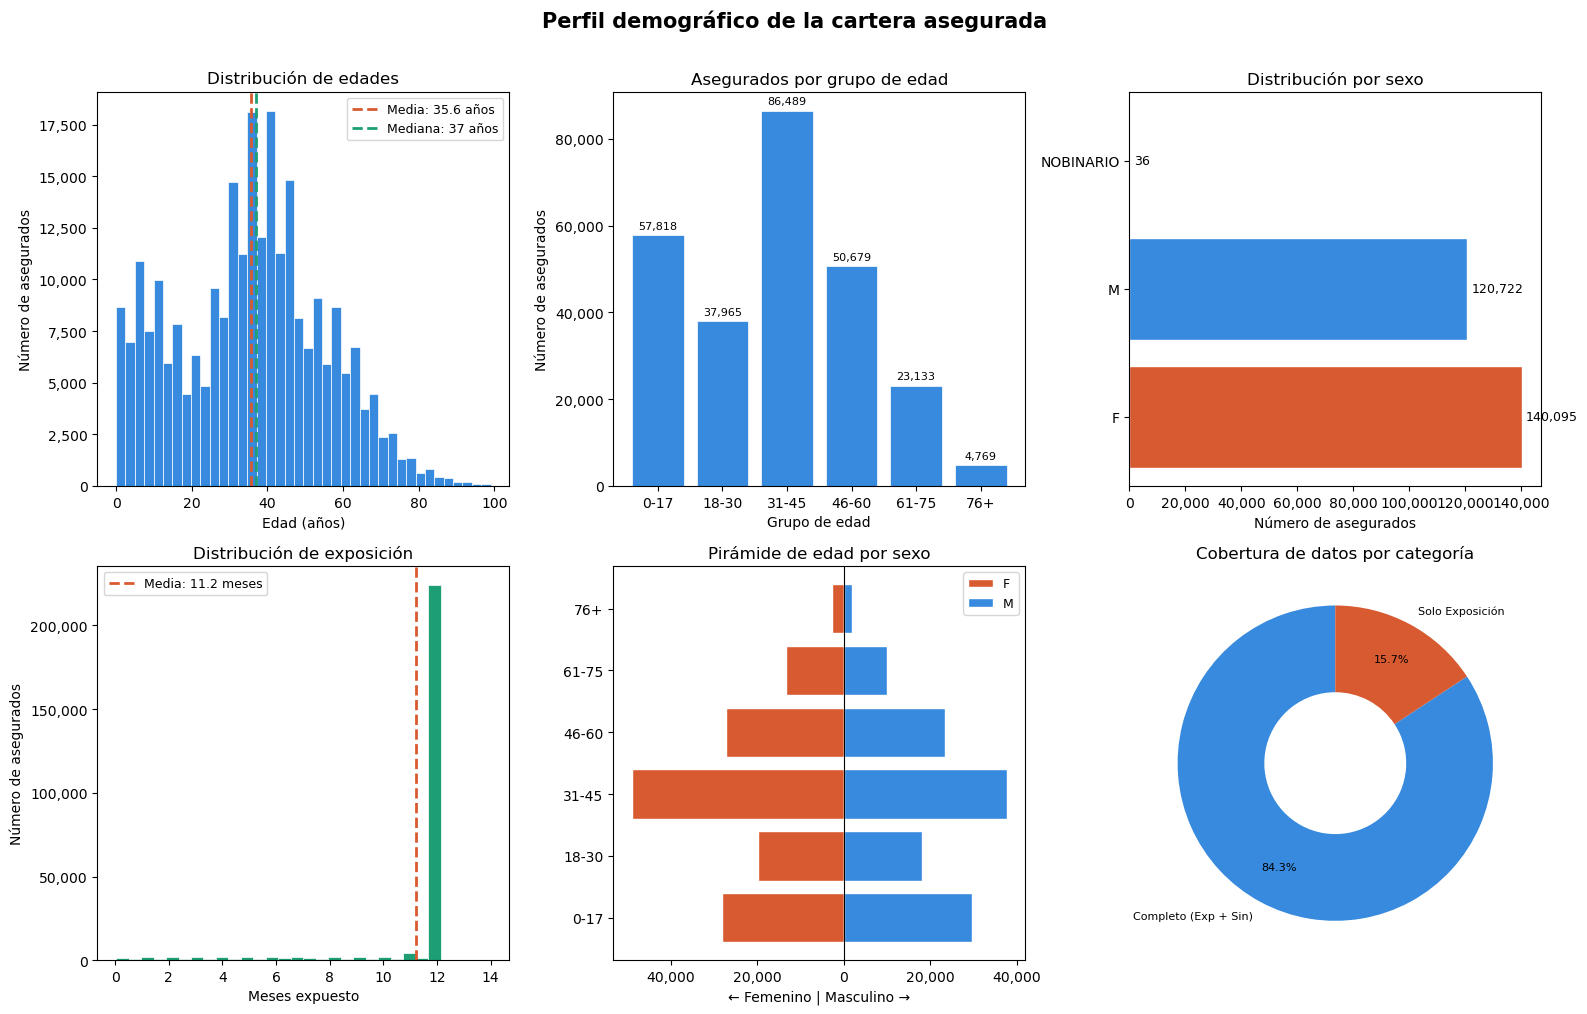

Guardado: eda_01_perfil_demografico.png


In [4]:
# ── PERFIL DEMOGRÁFICO DE LOS AFILIADOS ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Perfil demográfico de la cartera asegurada', fontsize=15, fontweight='bold', y=1.01)

AZUL   = '#378ADD'
CORAL  = '#D85A30'
TEAL   = '#1D9E75'
MORADO = '#7F77DD'

# 1. Distribución de edades (histograma)
ax = axes[0, 0]
ax.hist(df_eda['edad'].dropna(), bins=40, color=AZUL, edgecolor='white', linewidth=0.5)
ax.axvline(df_eda['edad'].mean(), color=CORAL, linewidth=2, linestyle='--', label=f'Media: {df_eda["edad"].mean():.1f} años')
ax.axvline(df_eda['edad'].median(), color=TEAL, linewidth=2, linestyle='--', label=f'Mediana: {df_eda["edad"].median():.0f} años')
ax.set_title('Distribución de edades')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Número de asegurados')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 2. Asegurados por grupo de edad (barplot)
ax = axes[0, 1]
conteo_edad = df_eda['grupo_edad'].value_counts().sort_index()
bars = ax.bar(conteo_edad.index, conteo_edad.values, color=AZUL, edgecolor='white', linewidth=0.5)
ax.bar_label(bars, fmt='{:,.0f}', fontsize=8, padding=3)
ax.set_title('Asegurados por grupo de edad')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Número de asegurados')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 3. Distribución por sexo (barplot horizontal)
ax = axes[0, 2]
conteo_sexo = df_eda['Sexo_Cd_limpio'].value_counts()
colores_sexo = [CORAL if x == 'F' else AZUL if x == 'M' else MORADO for x in conteo_sexo.index]
bars = ax.barh(conteo_sexo.index, conteo_sexo.values, color=colores_sexo, edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
ax.set_title('Distribución por sexo')
ax.set_xlabel('Número de asegurados')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 4. Distribución de exposición en meses (histograma)
ax = axes[1, 0]
ax.hist(df_eda['meses_expuesto_total'].clip(0, 14), bins=30, color=TEAL, edgecolor='white', linewidth=0.5)
ax.axvline(df_eda['meses_expuesto_total'].mean(), color=CORAL, linewidth=2, linestyle='--',
           label=f'Media: {df_eda["meses_expuesto_total"].mean():.1f} meses')
ax.set_title('Distribución de exposición')
ax.set_xlabel('Meses expuesto')
ax.set_ylabel('Número de asegurados')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 5. Pirámide de edad por sexo
ax = axes[1, 1]
df_piramide = df_eda.groupby(['grupo_edad', 'Sexo_Cd_limpio']).size().unstack(fill_value=0)
if 'F' in df_piramide.columns and 'M' in df_piramide.columns:
    grupos = df_piramide.index.tolist()
    ax.barh(grupos, -df_piramide['F'], color=CORAL, label='F', edgecolor='white')
    ax.barh(grupos, df_piramide['M'], color=AZUL, label='M', edgecolor='white')
    ax.set_title('Pirámide de edad por sexo')
    ax.set_xlabel('← Femenino | Masculino →')
    ax.axvline(0, color='black', linewidth=0.8)
    vals = ax.get_xticks()
    ax.set_xticklabels([f'{abs(v):,.0f}' for v in vals])
    ax.legend(fontsize=9)

# 6. Categoría de cobertura (donut chart)
ax = axes[1, 2]
cat_cob = df_eda['categoria_cobertura'].value_counts()
colores_cob = [AZUL, CORAL, MORADO, TEAL]
wedges, texts, autotexts = ax.pie(
    cat_cob.values,
    labels=cat_cob.index,
    autopct='%1.1f%%',
    colors=colores_cob[:len(cat_cob)],
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55)
 )
for t in texts:
    t.set_fontsize(8)
for at in autotexts:
    at.set_fontsize(8)
ax.set_title('Cobertura de datos por categoría')

plt.tight_layout()
plt.savefig('eda_01_perfil_demografico.png', bbox_inches='tight', dpi=150)
plt.show()
print('Guardado: eda_01_perfil_demografico.png')

### Interpretación del análisis de perfil demográfico

- Distribución de edades: La mayoría de los asegurados tiene entre 20 y 50 años, con una edad promedio de 35.6 años y mediana de 37. Esto indica una cartera predominantemente joven-adulta.
- Asegurados por grupo de edad: El grupo más numeroso es el de 31-45 años, seguido por 0-17 y 46-60, lo que muestra una alta proporción de adultos, niños y jóvenes.
- Distribución por sexo: Hay una ligera mayoría de mujeres (F) sobre hombres (M), y un grupo muy pequeño de personas no binarias.
- Distribución de exposición: La mayoría estuvo asegurada casi todo el año (promedio 11.2 meses), lo que implica buena permanencia en la póliza.
- Pirámide de edad por sexo: La distribución por edad es similar entre hombres y mujeres, con una base ancha en los grupos jóvenes y adultos, y menor presencia en edades avanzadas.
- Cobertura de datos: El 84.3% de los asegurados tiene información completa de exposición y siniestros, mientras que el 15.7% solo tiene datos de exposición.

## PASO 3: Los que utilizan el seguro

Profe importante para la interpretación grafica (Tasa de uso por condiciones preexistentes) entender que se lee " Del 100% de las personas que dijeron tener x cantidad de condiciones preexistentes y% uso el seguro entonces su relación inversa seria  (1-x) No lo uso"


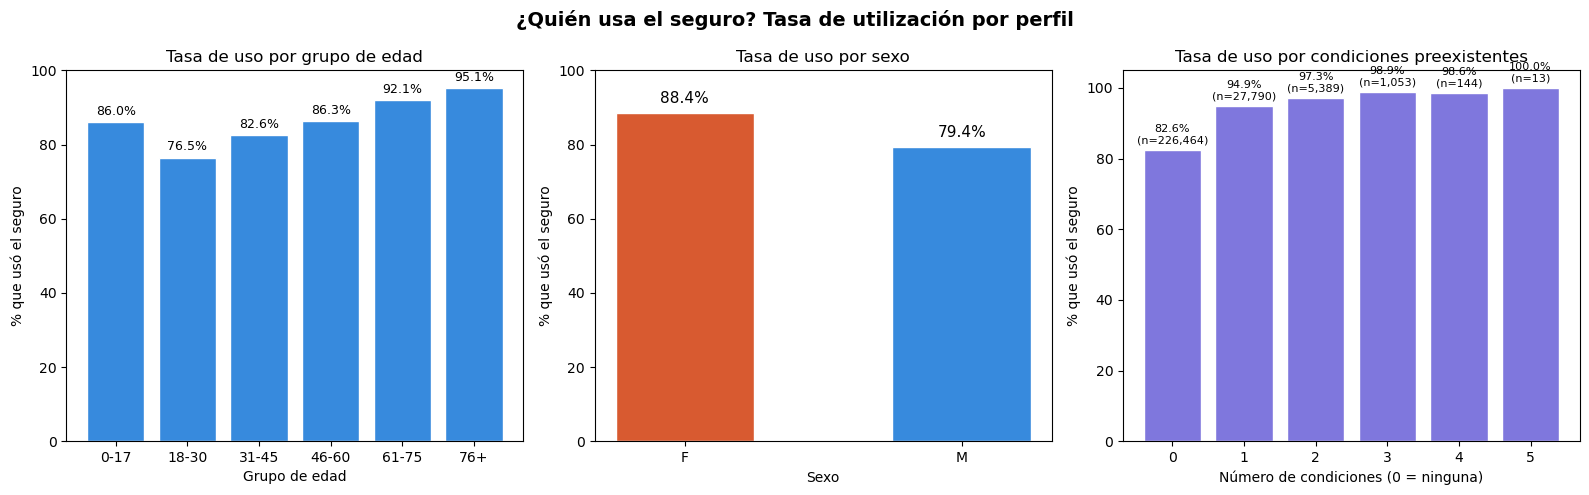

In [5]:
# ── TASA DE USO POR PERFIL ────────────────────────────────────────────────────
df_eda['uso_seguro'] = df_eda['n_reclamaciones'].fillna(0).gt(0).map({True: 'Usó el seguro', False: 'No usó el seguro'})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('¿Quién usa el seguro? Tasa de utilización por perfil', fontsize=14, fontweight='bold')

# 1. Tasa de uso por grupo de edad
ax = axes[0]
tasa_edad = (
    df_eda.groupby('grupo_edad', observed=True)['uso_seguro']
    .apply(lambda x: (x == 'Usó el seguro').mean() * 100)
    .reset_index(name='tasa_uso_pct')
)
bars = ax.bar(tasa_edad['grupo_edad'], tasa_edad['tasa_uso_pct'],
              color=AZUL, edgecolor='white')
ax.bar_label(bars, fmt='{:.1f}%', fontsize=9, padding=3)
ax.set_title('Tasa de uso por grupo de edad')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('% que usó el seguro')
ax.set_ylim(0, 100)

# 2. Tasa de uso por sexo
ax = axes[1]
tasa_sexo = (
    df_eda[df_eda['Sexo_Cd_limpio'].isin(['F', 'M'])]
    .groupby('Sexo_Cd_limpio')['uso_seguro']
    .apply(lambda x: (x == 'Usó el seguro').mean() * 100)
    .reset_index(name='tasa_uso_pct')
)
colores = [CORAL if s == 'F' else AZUL for s in tasa_sexo['Sexo_Cd_limpio']]
bars = ax.bar(tasa_sexo['Sexo_Cd_limpio'], tasa_sexo['tasa_uso_pct'],
              color=colores, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='{:.1f}%', fontsize=11, padding=5)
ax.set_title('Tasa de uso por sexo')
ax.set_xlabel('Sexo')
ax.set_ylabel('% que usó el seguro')
ax.set_ylim(0, 100)

# 3. Tasa de uso por número de condiciones preexistentes (con n por grupo)
ax = axes[2]
tasa_cond = (
    df_eda.groupby('num_condiciones', observed=True)['uso_seguro']
    .agg(
        n_afiliados='size',
        tasa_uso_pct=lambda x: (x == 'Usó el seguro').mean() * 100
    )
    .reset_index()
    .sort_values('num_condiciones')
)
bars = ax.bar(tasa_cond['num_condiciones'].astype(str), tasa_cond['tasa_uso_pct'],
              color=MORADO, edgecolor='white')
labels = [f"{p:.1f}%\n(n={n:,})" for p, n in zip(tasa_cond['tasa_uso_pct'], tasa_cond['n_afiliados'])]
ax.bar_label(bars, labels=labels, fontsize=8, padding=3)
ax.set_title('Tasa de uso por condiciones preexistentes')
ax.set_xlabel('Número de condiciones (0 = ninguna)')
ax.set_ylabel('% que usó el seguro')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('eda_02_tasa_utilizacion.png', bbox_inches='tight', dpi=150)
plt.show()

### Interpretación del análisis de tasa de utilización
- **Por grupo de edad:** El uso del seguro aumenta con la edad, siendo más alto en adultos mayores (más del 90%) y más bajo en jóvenes adultos.
- **Por sexo:** Las mujeres usan el seguro con mayor frecuencia que los hombres.
- **Por condiciones preexistentes:** A mayor número de condiciones, mayor es la tasa de uso, llegando al 100% en quienes reportan 5 condiciones.

## Paso 4: Distribución del Costo

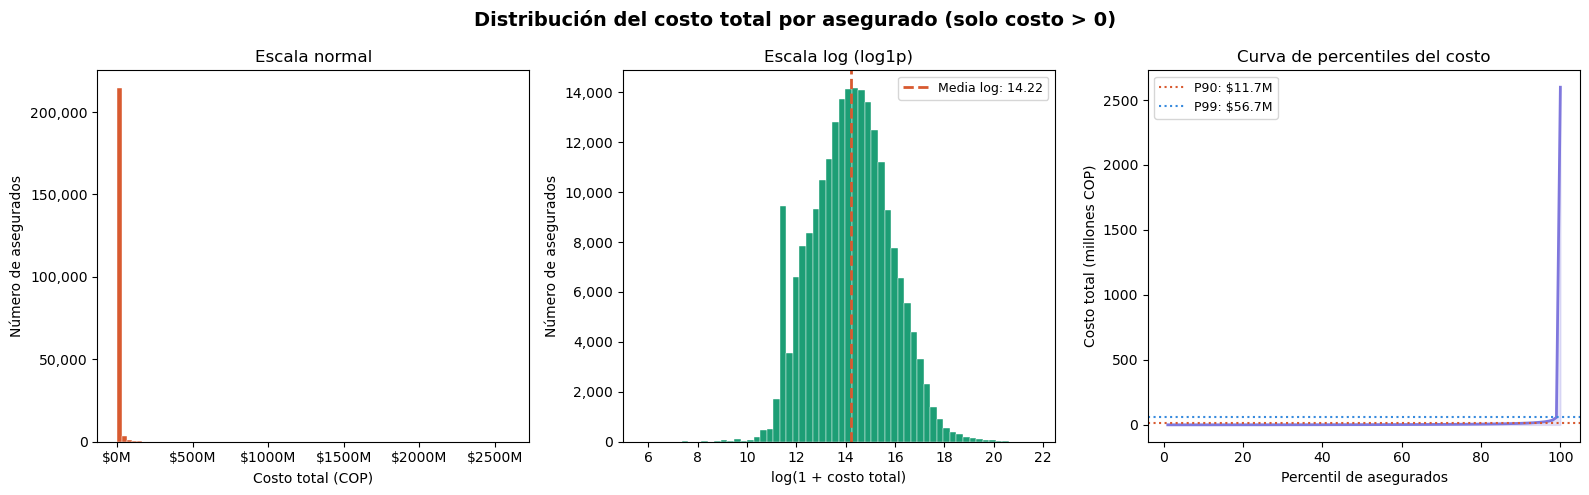


=== Cobertura de costo en la cartera ===
Total asegurados: 260,853
Sin costo para la aseguradora (total_pagado = 0): 41,053 (15.7%)
Con costo para la asegurados(total_pagado > 0): 219,800 (84.3%)

=== Percentiles clave del costo (quienes reclamaron) ===
  Percentil  25: $        486,463
  Percentil  50: $      1,512,496
  Percentil  75: $      4,410,960
  Percentil  90: $     11,717,115
  Percentil  95: $     20,239,760
  Percentil  99: $     56,674,465


In [6]:
# ── DISTRIBUCIÓN DE COSTOS ────────────────────────────────────────────────────
import numpy as np

total_asegurados = len(df_eda)
n_con_costo = (df_eda['total_pagado'] > 0).sum()
n_sin_costo = total_asegurados - n_con_costo
pct_sin_costo = n_sin_costo / total_asegurados * 100

# Solo asegurados con costo > 0 para analizar severidad
df_con_costo = df_eda[df_eda['total_pagado'] > 0].copy()
df_con_costo['log_costo'] = np.log1p(df_con_costo['total_pagado'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución del costo total por asegurado (solo costo > 0)', fontsize=14, fontweight='bold')

# 1. Distribución en escala normal
ax = axes[0]
ax.hist(df_con_costo['total_pagado'], bins=80, color=CORAL, edgecolor='white', linewidth=0.3)
ax.set_title('Escala normal')
ax.set_xlabel('Costo total (COP)')
ax.set_ylabel('Número de asegurados')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 2. Distribución en escala logarítmica
ax = axes[1]
ax.hist(df_con_costo['log_costo'], bins=60, color=TEAL, edgecolor='white', linewidth=0.3)
ax.axvline(
    df_con_costo['log_costo'].mean(),
    color=CORAL, linewidth=2, linestyle='--',
    label=f'Media log: {df_con_costo["log_costo"].mean():.2f}'
)
ax.set_title('Escala log (log1p)')
ax.set_xlabel('log(1 + costo total)')
ax.set_ylabel('Número de asegurados')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 3. Curva de percentiles del costo
ax = axes[2]
percentiles = np.arange(1, 101)
valores_pct = np.percentile(df_con_costo['total_pagado'], percentiles)
ax.plot(percentiles, valores_pct / 1e6, color=MORADO, linewidth=2)
ax.fill_between(percentiles, valores_pct / 1e6, alpha=0.2, color=MORADO)
ax.set_title('Curva de percentiles del costo')
ax.set_xlabel('Percentil de asegurados')
ax.set_ylabel('Costo total (millones COP)')

# Marcar P90 y P99
p90 = np.percentile(df_con_costo['total_pagado'], 90)
p99 = np.percentile(df_con_costo['total_pagado'], 99)
ax.axhline(p90 / 1e6, color=CORAL, linestyle=':', linewidth=1.5, label=f'P90: ${p90/1e6:.1f}M')
ax.axhline(p99 / 1e6, color=AZUL, linestyle=':', linewidth=1.5, label=f'P99: ${p99/1e6:.1f}M')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_03_distribucion_costos.png', bbox_inches='tight', dpi=150)
plt.show()

# Resumen complementario de negocio
print('\n=== Cobertura de costo en la cartera ===')
print(f'Total asegurados: {total_asegurados:,}')
print(f'Sin costo para la aseguradora (total_pagado = 0): {n_sin_costo:,} ({pct_sin_costo:.1f}%)')
print(f'Con costo para la asegurados(total_pagado > 0): {n_con_costo:,} ({100 - pct_sin_costo:.1f}%)')

print('\n=== Percentiles clave del costo (quienes reclamaron) ===')
for p in [25, 50, 75, 90, 95, 99]:
    val = np.percentile(df_con_costo['total_pagado'], p)
    print(f'  Percentil {p:3d}: ${val:>15,.0f}')

### Interpretación del análisis  de distribución de costos

- En escala normal, la mayoría de los asegurados tiene costos muy bajos o nulos, y solo unos pocos concentran gastos extremadamente altos.
- En escala logarítmica, la distribución se ve más simétrica y permite visualizar mejor los grupos intermedios.
- En la curva de percentiles, el 90% de los asegurados tiene costos menores a $11.7 millones, pero el 1% más costoso supera los $56 millones.

## Costo por perfil 

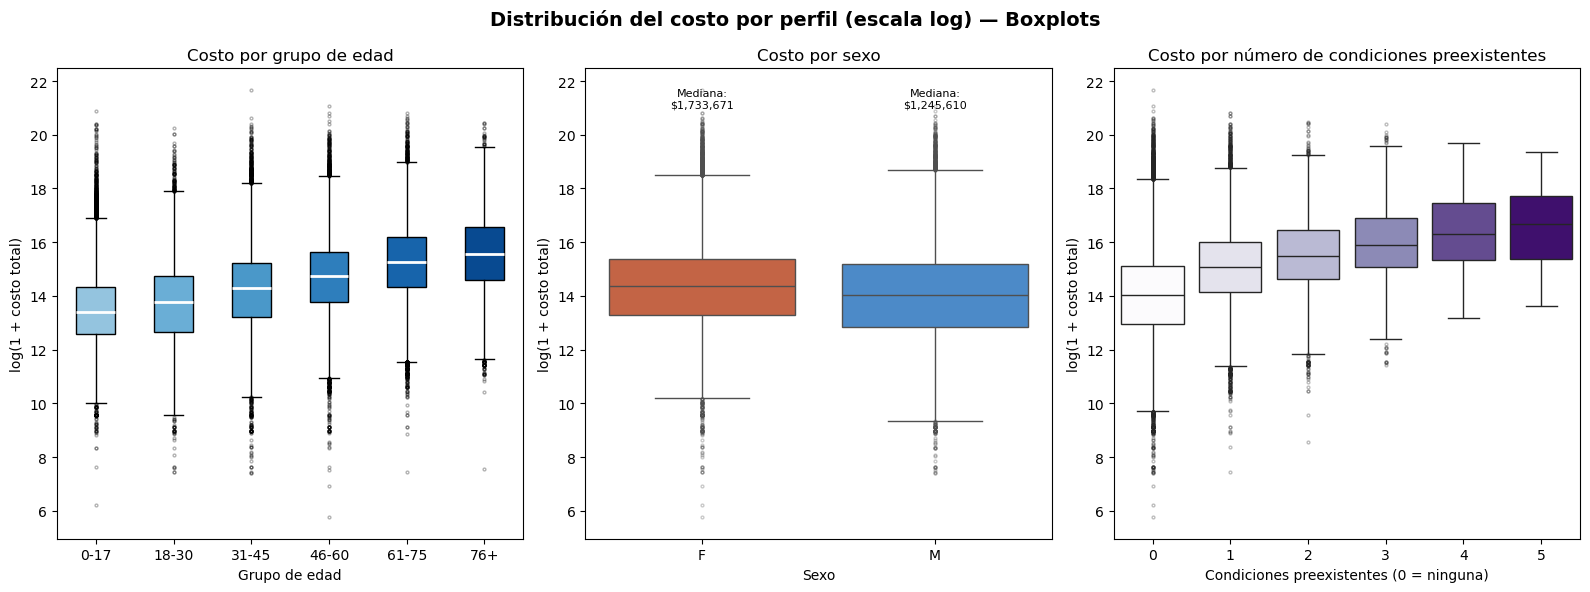

Guardado: eda_04_boxplots_costo_perfil.png


In [7]:
# ─BOXPLOTS: COSTO POR PERFIL ────────────────────────────────────────────────

# Usamos escala log para que los grupos pequeños y los costos bajos también sean visibles
df_box = df_con_costo.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Distribución del costo por perfil (escala log) — Boxplots', fontsize=14, fontweight='bold')

# 1. Costo por grupo de edad
ax = axes[0]
grupos_orden = ['0-17', '18-30', '31-45', '46-60', '61-75', '76+']
data_edad = [df_box[df_box['grupo_edad'] == g]['log_costo'].dropna().values for g in grupos_orden]
bp = ax.boxplot(
    data_edad,
    tick_labels=grupos_orden,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
 )
for patch, color in zip(bp['boxes'], plt.cm.Blues(np.linspace(0.4, 0.9, len(grupos_orden)))):
    patch.set_facecolor(color)
ax.set_title('Costo por grupo de edad')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('log(1 + costo total)')

# 2. Costo por sexo
ax = axes[1]
df_sexo_box = df_box[df_box['Sexo_Cd_limpio'].isin(['F', 'M'])]
sns.boxplot(
    data=df_sexo_box,
    x='Sexo_Cd_limpio',
    y='log_costo',
    hue='Sexo_Cd_limpio',
    palette={'F': CORAL, 'M': AZUL},
    legend=False,
    ax=ax,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
 )
ax.set_title('Costo por sexo')
ax.set_xlabel('Sexo')
ax.set_ylabel('log(1 + costo total)')

y_top = df_sexo_box['log_costo'].max() * 0.97
for i, sexo in enumerate(['F', 'M']):
    med = df_sexo_box[df_sexo_box['Sexo_Cd_limpio'] == sexo]['total_pagado'].median()
    ax.text(i, y_top, f'Mediana:\n${med:,.0f}', ha='center', fontsize=8, color='black')

# 3. Costo por número de condiciones preexistentes
ax = axes[2]
sns.boxplot(
    data=df_box,
    x='num_condiciones',
    y='log_costo',
    hue='num_condiciones',
    palette='Purples',
    legend=False,
    ax=ax,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
 )
ax.set_title('Costo por número de condiciones preexistentes')
ax.set_xlabel('Condiciones preexistentes (0 = ninguna)')
ax.set_ylabel('log(1 + costo total)')

plt.tight_layout()
plt.savefig('eda_04_boxplots_costo_perfil.png', bbox_inches='tight', dpi=150)
plt.show()

print('Guardado: eda_04_boxplots_costo_perfil.png')

### Interpretación del análisis de costo_perfil

- Por grupo de edad: El costo tiende a aumentar con la edad, siendo más alto y variable en adultos mayores.
- Por sexo: Las mujeres presentan una mediana de costo superior a la de los hombres, aunque ambos sexos muestran alta dispersión y valores extremos.
- Por número de condiciones preexistentes: A mayor número de condiciones, mayor es el costo mediano y la dispersión; quienes tienen más condiciones generan mayores gastos.

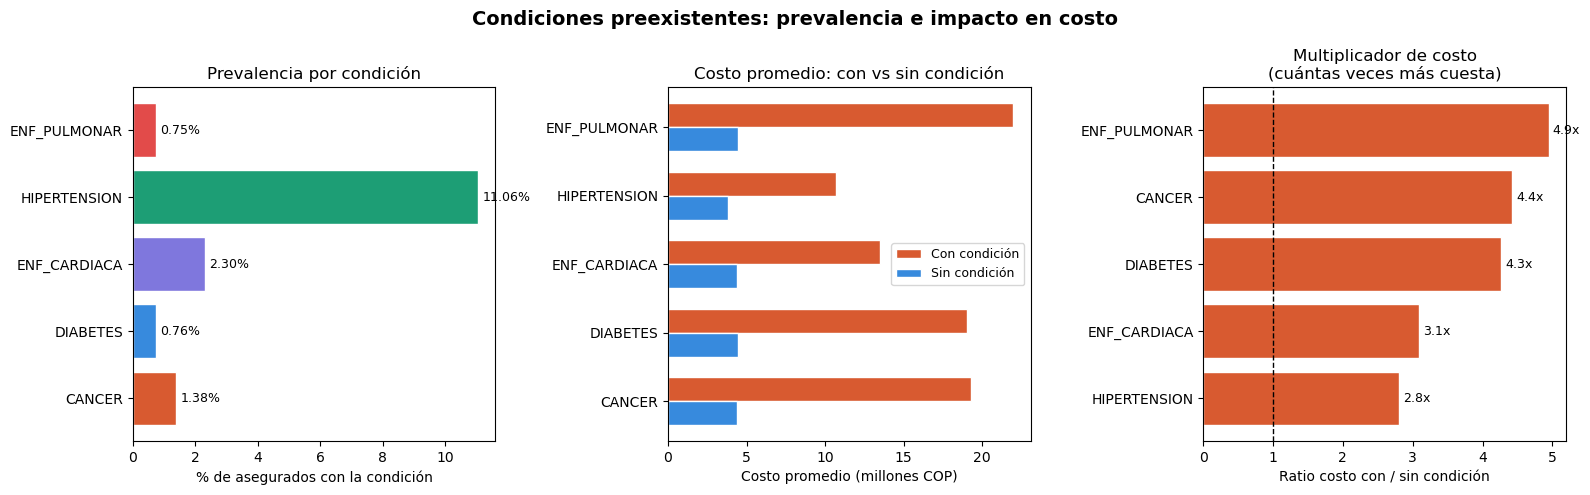

In [8]:
# ── CONDICIONES PREEXISTENTES ─────────────────────────────────────────────────
cols_cond = ['CANCER', 'DIABETES', 'ENF_CARDIACA', 'HIPERTENSION', 'ENF_PULMONAR']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Condiciones preexistentes: prevalencia e impacto en costo', fontsize=14, fontweight='bold')

# 1. Prevalencia de cada condición
ax = axes[0]
prevalencia = df_eda[cols_cond].mean() * 100
colores_cond = [CORAL, AZUL, MORADO, TEAL, '#E24B4A']
bars = ax.barh(prevalencia.index, prevalencia.values, color=colores_cond, edgecolor='white')
ax.bar_label(bars, fmt='{:.2f}%', padding=3, fontsize=9)
ax.set_title('Prevalencia por condición')
ax.set_xlabel('% de asegurados con la condición')

# 2. Costo promedio: con vs sin cada condición
ax = axes[1]
resultados = []
for cond in cols_cond:
    con = df_eda[df_eda[cond] == 1]['total_pagado'].mean()
    sin = df_eda[df_eda[cond] == 0]['total_pagado'].mean()
    ratio = con / sin if sin > 0 else 0
    resultados.append({'condicion': cond, 'Con': con, 'Sin': sin, 'ratio': ratio})

df_res = pd.DataFrame(resultados).set_index('condicion')
x = np.arange(len(cols_cond))
w = 0.35
ax.barh(x + w / 2, df_res['Con'] / 1e6, w, label='Con condición', color=CORAL, edgecolor='white')
ax.barh(x - w / 2, df_res['Sin'] / 1e6, w, label='Sin condición', color=AZUL, edgecolor='white')
ax.set_yticks(x)
ax.set_yticklabels(cols_cond)
ax.set_title('Costo promedio: con vs sin condición')
ax.set_xlabel('Costo promedio (millones COP)')
ax.legend(fontsize=9)

# 3. Factor multiplicador (ratio con/sin)
ax = axes[2]
df_ratio = df_res['ratio'].sort_values(ascending=True)
colores_ratio = [CORAL if r > 2 else AZUL for r in df_ratio.values]
bars = ax.barh(df_ratio.index, df_ratio.values, color=colores_ratio, edgecolor='white')
ax.bar_label(bars, fmt='{:.1f}x', padding=3, fontsize=9)
ax.axvline(1, color='black', linewidth=1, linestyle='--')
ax.set_title('Multiplicador de costo\n(cuántas veces más cuesta)')
ax.set_xlabel('Ratio costo con / sin condición')

plt.tight_layout()
plt.savefig('eda_05_condiciones_preexistentes.png', bbox_inches='tight', dpi=150)
plt.show()


### Interpretación del análisis de condiciones preexistentes

- Prevalencia: La condición más frecuente es la hipertensión (11%), mientras que cáncer, diabetes, enfermedad cardíaca y pulmonar son poco comunes (menos del 2.5% cada una).
Costo promedio: Los asegurados con estas condiciones 
- presentan costos promedio mucho más altos que quienes no las tienen. Por ejemplo, enfermedad pulmonar, cáncer o diabetes pueden costar más de 4 veces que quienes no presentan la condición.
- Multiplicador de costo: El mayor impacto se observa en enfermedad pulmonar, cáncer y diabetes, donde el costo promedio es entre 4 y 5 veces mayor. Incluso la hipertensión multiplica el costo casi 3 veces.

## Paso 5: Tipos de Reclamación 

Las columnas `rec_*` dicen cuántas veces usó cada tipo de servicio.
Esto permite entender qué servicios son más costosos y más frecuentes.

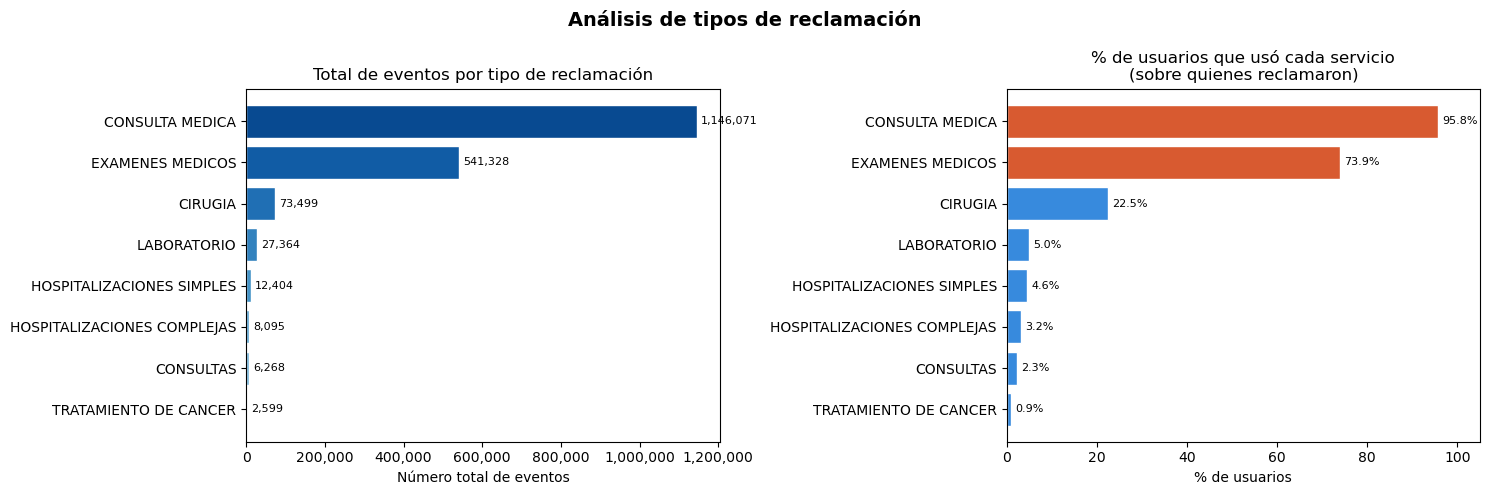


=== Costo promedio de quien usó cada servicio ===
  CIRUGIA                             $     13,525,463 | n=49,380
  CONSULTA MEDICA                     $      5,466,336 | n=210,533
  CONSULTAS                           $     36,203,415 | n=5,086
  EXAMENES MEDICOS                    $      6,835,546 | n=162,377
  HOSPITALIZACIONES COMPLEJAS         $     49,657,898 | n=7,065
  HOSPITALIZACIONES SIMPLES           $     26,485,802 | n=10,160
  LABORATORIO                         $      8,094,557 | n=11,061
  TRATAMIENTO DE CANCER               $     69,931,159 | n=1,970


In [9]:
# ── TIPOS DE RECLAMACIÓN ─────────────────────────────────────────────────────
cols_rec = [c for c in df_eda.columns if c.startswith('rec_')]
nombres_limpios = {c: c.replace('rec_', '') for c in cols_rec}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Análisis de tipos de reclamación', fontsize=14, fontweight='bold')

# 1. Frecuencia total de cada tipo (cuántos eventos en total)
ax = axes[0]
total_por_tipo = df_eda[cols_rec].sum().rename(nombres_limpios).sort_values(ascending=True)
colores_rec = plt.cm.Blues(np.linspace(0.4, 0.9, len(total_por_tipo)))
bars = ax.barh(total_por_tipo.index, total_por_tipo.values, color=colores_rec, edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=8)
ax.set_title('Total de eventos por tipo de reclamación')
ax.set_xlabel('Número total de eventos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 2. % de usuarios que usó cada tipo (sobre quienes reclamaron)
ax = axes[1]
pct_por_tipo = ((df_con_costo[cols_rec] > 0).mean() * 100).rename(nombres_limpios).sort_values(ascending=True)
colores_rec2 = [CORAL if p > 50 else AZUL for p in pct_por_tipo.values]
bars = ax.barh(pct_por_tipo.index, pct_por_tipo.values, color=colores_rec2, edgecolor='white')
ax.bar_label(bars, fmt='{:.1f}%', padding=3, fontsize=8)
ax.set_title('% de usuarios que usó cada servicio\n(sobre quienes reclamaron)')
ax.set_xlabel('% de usuarios')
ax.set_xlim(0, 105)

plt.tight_layout()
plt.savefig('eda_06_tipos_reclamacion.png', bbox_inches='tight', dpi=150)
plt.show()

# Tabla resumen de costo promedio por tipo
print('\n=== Costo promedio de quien usó cada servicio ===')
for col in sorted(cols_rec):
    nombre = col.replace('rec_', '')
    usuarios_tipo = df_eda[(df_eda[col] > 0) & (df_eda['total_pagado'] > 0)]
    if len(usuarios_tipo) > 0:
        print(f'  {nombre:<35} ${usuarios_tipo["total_pagado"].mean():>15,.0f} | n={len(usuarios_tipo):,}')

### Interpretación del análisis de tipos de reclamación

- **Frecuencia de eventos:** La mayoría de los eventos corresponden a consultas médicas y exámenes médicos, lo que indica que estos servicios son los más utilizados por los asegurados. Cirugías, hospitalizaciones y tratamientos de cáncer son mucho menos frecuentes.
- **Cobertura de servicios:** Prácticamente todos los usuarios que reclamaron usaron consultas médicas (95.8%) y una gran mayoría también exámenes médicos (73.9%). Los servicios de mayor complejidad, como cirugías, hospitalizaciones y tratamientos de cáncer, son utilizados por una minoría.
- **Implicación:** El seguro se usa principalmente para atención ambulatoria y diagnóstica, mientras que los eventos de alto costo (cirugías, hospitalizaciones, cáncer) son poco frecuentes pero pueden tener un gran impacto económico individual.


## Paso 6:  Comportamiento geografico

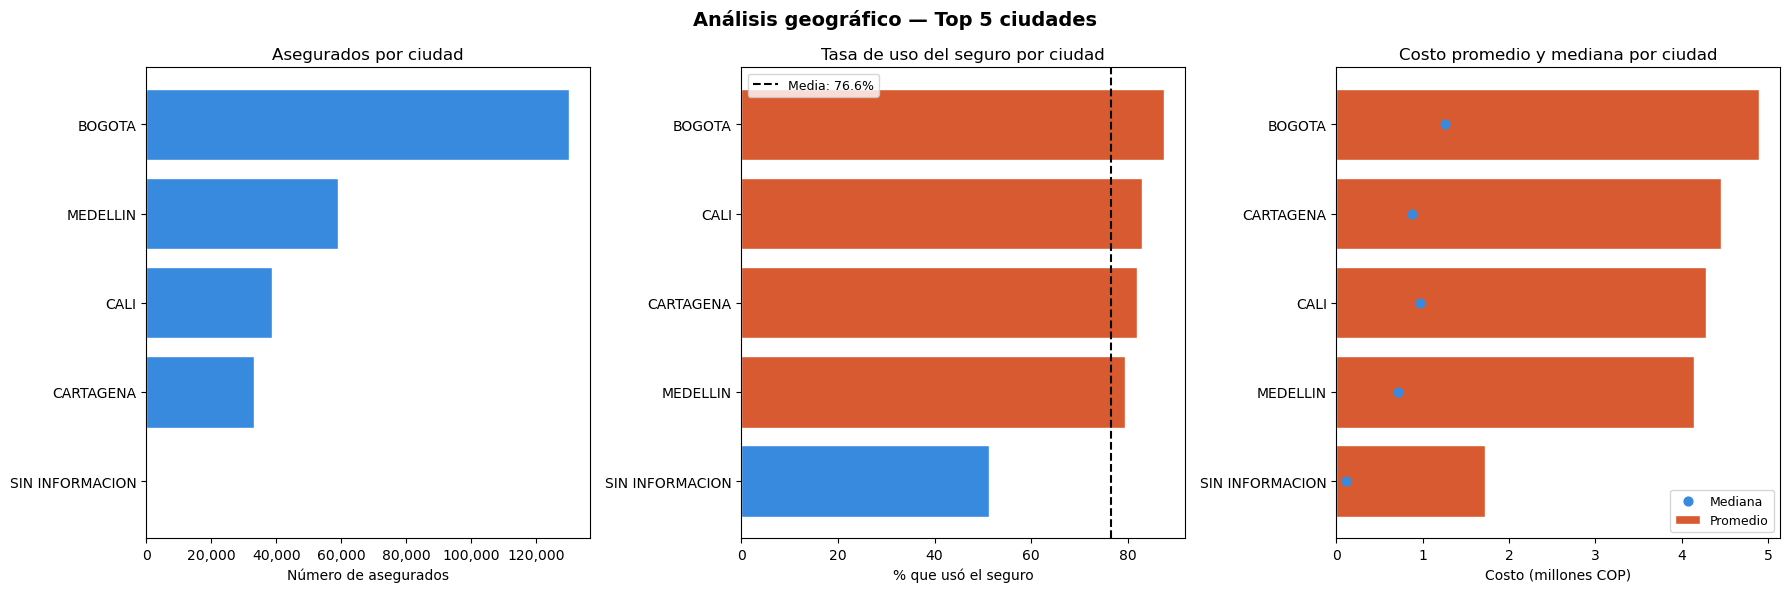

In [10]:
# ── ANÁLISIS GEOGRÁFICO ───────────────────────────────────────────────────────

df_ciudad = (
    df_eda.groupby('CIUDAD_NORM')
    .agg(
        n_asegurados=('Afiliado_Id', 'count'),
        tasa_uso=('uso_seguro', lambda x: (x == 'Usó el seguro').mean() * 100),
        costo_promedio=('total_pagado', 'mean'),
        costo_mediano=('total_pagado', 'median')
    )
    .sort_values('n_asegurados', ascending=False)
    .head(15)
 )

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análisis geográfico — Top 5 ciudades', fontsize=14, fontweight='bold')

# 1. Asegurados por ciudad
ax = axes[0]
df_sorted = df_ciudad.sort_values('n_asegurados')
ax.barh(df_sorted.index, df_sorted['n_asegurados'], color=AZUL, edgecolor='white')
ax.set_title('Asegurados por ciudad')
ax.set_xlabel('Número de asegurados')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 2. Tasa de uso por ciudad
ax = axes[1]
df_sorted2 = df_ciudad.sort_values('tasa_uso')
colores_uso = [CORAL if t > df_ciudad['tasa_uso'].mean() else AZUL for t in df_sorted2['tasa_uso']]
ax.barh(df_sorted2.index, df_sorted2['tasa_uso'], color=colores_uso, edgecolor='white')
ax.axvline(
    df_ciudad['tasa_uso'].mean(),
    color='black',
    linewidth=1.5,
    linestyle='--',
    label=f"Media: {df_ciudad['tasa_uso'].mean():.1f}%"
 )
ax.set_title('Tasa de uso del seguro por ciudad')
ax.set_xlabel('% que usó el seguro')
ax.legend(fontsize=9)

# 3. Costo promedio por ciudad (con mediana superpuesta)
ax = axes[2]
df_sorted3 = df_ciudad.sort_values('costo_promedio')
ax.barh(df_sorted3.index, df_sorted3['costo_promedio'] / 1e6, color=CORAL, edgecolor='white', label='Promedio')
ax.scatter(df_sorted3['costo_mediano'] / 1e6, df_sorted3.index, color=AZUL, zorder=5, s=40, label='Mediana')
ax.set_title('Costo promedio y mediana por ciudad')
ax.set_xlabel('Costo (millones COP)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_07_geografico.png', bbox_inches='tight', dpi=150)
plt.show()

In [11]:
#Codigo para conocer numero asegurados por ciudad
tabla_ciudad = (
    df_eda.groupby('CIUDAD_NORM')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='n_asegurados')
)
display(tabla_ciudad)

,CIUDAD_NORM,n_asegurados
0,BOGOTA,130007
1,MEDELLIN,59008
2,CALI,38759
3,CARTAGENA,33038
4,SIN INFORMACION,41


In [12]:
df_eda.groupby('CIUDAD_NORM')['total_pagado'].mean()

CIUDAD_NORM
BOGOTA             4.894405e+06
CALI               4.285378e+06
CARTAGENA          4.460345e+06
MEDELLIN           4.145940e+06
SIN INFORMACION    1.717429e+06
Name: total_pagado, dtype: float64

In [13]:
promedio_general = df_eda['total_pagado'].mean()
print(f'Costo promedio general: ${promedio_general:,.0f}')

Costo promedio general: $4,579,126


### Interpretación del análisis geográfico
- **Concentración de asegurados:** La mayoría de los asegurados se encuentran en grandes ciudades como Bogotá, Medellín, Cali y Cartagena. Esto refleja la concentración urbana de la cartera y puede estar asociado a una mayor demanda de servicios de salud en estas zonas.
- **Tasa de uso por ciudad:** Aunque la tasa de uso del seguro es alta en todas las ciudades principales (por encima del promedio general), existen diferencias. Bogotá y Cali presentan las tasas más altas, lo que puede indicar mayor acceso o necesidad de servicios médicos.
- **Costo promedio y mediano:** El costo promedio y la mediana por ciudad muestran que, aunque el gasto es alto en todas las ciudades principales, existen diferencias importantes. Bogotá tiene el mayor costo promedio, pero la mediana es mucho menor, lo que sugiere que unos pocos casos generan gastos muy altos. La diferencia entre promedio y mediana es clave para identificar ciudades con mayor concentración de casos costosos.


## Paso 7: Mapa de Correlaciones


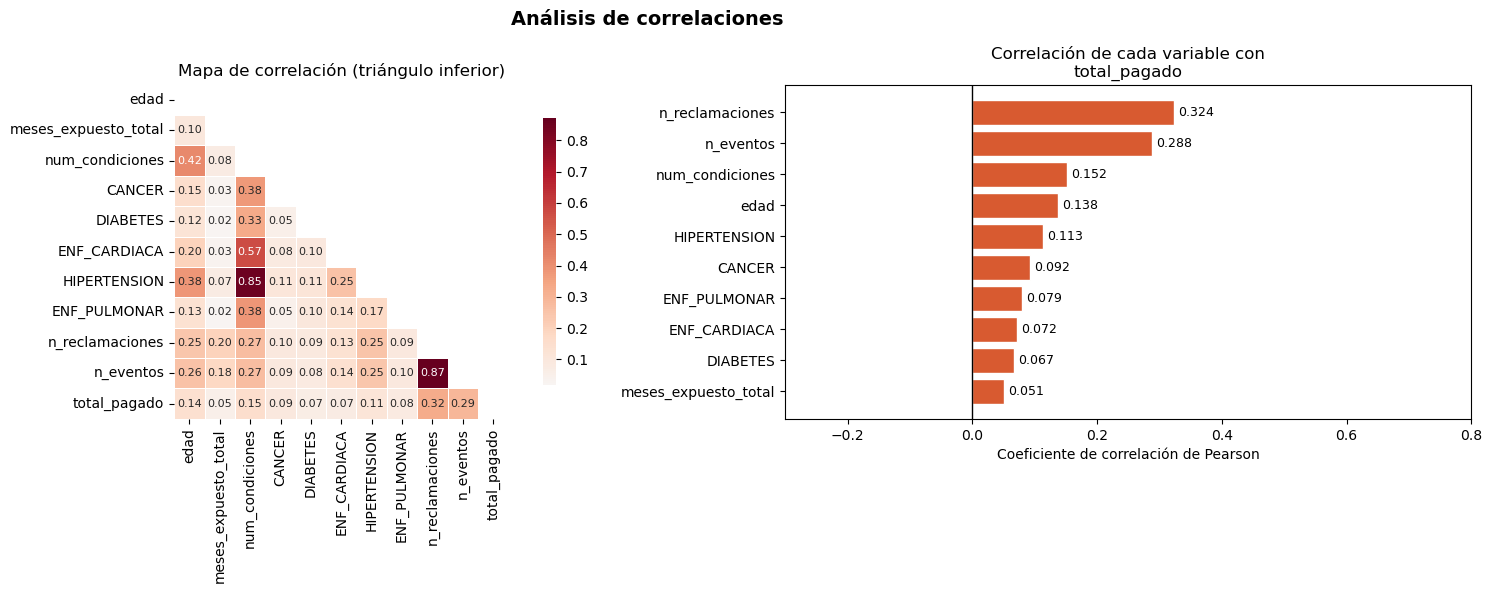


=== Top variables más correlacionadas con total_pagado ===
n_reclamaciones         0.323916
n_eventos               0.288120
num_condiciones         0.152329
edad                    0.137601
HIPERTENSION            0.113318
CANCER                  0.091830
ENF_PULMONAR            0.079455
ENF_CARDIACA            0.072123
DIABETES                0.066548
meses_expuesto_total    0.050690


In [14]:
# ── MAPA DE CORRELACIONES ─────────────────────────────────────────────────────

cols_numericas = [
    'edad', 'meses_expuesto_total', 'num_condiciones',
    'CANCER', 'DIABETES', 'ENF_CARDIACA', 'HIPERTENSION', 'ENF_PULMONAR',
    'n_reclamaciones', 'n_eventos', 'total_pagado'
]

corr = df_eda[cols_numericas].corr()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Análisis de correlaciones', fontsize=14, fontweight='bold')

# 1) Heatmap completo
ax = axes[0]
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Mapa de correlación (triángulo inferior)')

# 2) Correlación con total_pagado
ax = axes[1]
corr_objetivo = corr['total_pagado'].drop('total_pagado').sort_values()
colores_corr = [CORAL if c > 0 else AZUL for c in corr_objetivo.values]
bars = ax.barh(corr_objetivo.index, corr_objetivo.values, color=colores_corr, edgecolor='white')
ax.bar_label(bars, fmt='{:.3f}', padding=3, fontsize=9)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Correlación de cada variable con\ntotal_pagado')
ax.set_xlabel('Coeficiente de correlación de Pearson')
ax.set_xlim(-0.3, 0.8)

plt.tight_layout()
plt.savefig('eda_08_correlaciones.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n=== Top variables más correlacionadas con total_pagado ===')
print(corr_objetivo.sort_values(ascending=False).to_string())

### Interpretación del análisis de correlaciones
- **Mapa de correlación:** El heatmap muestra cómo se relacionan las variables numéricas entre sí. Las correlaciones más altas se observan entre el número de reclamaciones, el número de eventos y el costo total pagado, lo que es lógico porque más reclamaciones y eventos suelen implicar mayores costos.
- **Variables más asociadas al costo:** El gráfico de barras indica que el número de reclamaciones y eventos son los factores que más explican el costo total pagado. También influyen el número de condiciones preexistentes, la edad y la presencia de hipertensión.
- **Correlaciones bajas:** Variables como meses expuesto, diabetes y enfermedad cardíaca tienen una correlación baja con el costo total, lo que sugiere que su impacto es menor o está mediado por otras variables.


## Paso 8: Hatmaps Cruzados

En este paso analizamos la combinación de variables clave (edad, sexo y número de condiciones preexistentes) para identificar perfiles de asegurados que concentran los mayores costos. Utilizamos heatmaps para visualizar cómo el costo mediano varía según estos perfiles, lo que nos  permitiría  segmentar la cartera y enfocar estrategias de gestión y tarificación en los grupos de mayor riesgo.

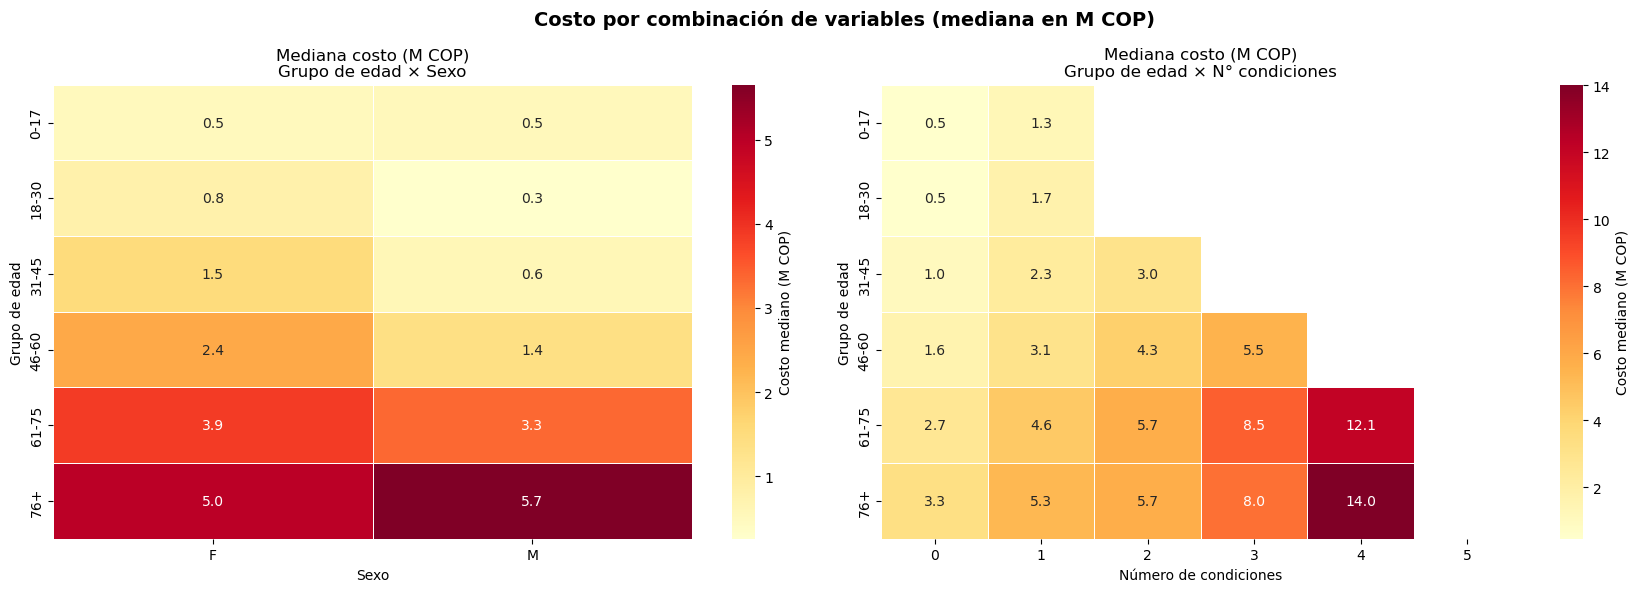

In [15]:
# ── HEATMAPS CRUZADOS (INTERACCIONES) ─────────────────────────────────────────
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Costo por combinación de variables (mediana en M COP)', fontsize=14, fontweight='bold')

# 1) Mediana de costo: Grupo de edad × Sexo
ax = axes[0]
base_sexo = df_eda[df_eda['Sexo_Cd_limpio'].isin(['F', 'M'])].copy()

pivot_edad_sexo = (
    base_sexo
    .groupby(['grupo_edad', 'Sexo_Cd_limpio'], observed=True)['total_pagado']
    .median()
    .unstack() / 1e6
)

n_edad_sexo = (
    base_sexo
    .groupby(['grupo_edad', 'Sexo_Cd_limpio'], observed=True)['Afiliado_Id']
    .count()
    .unstack()
)

# Enmascara celdas con n bajo (ej. < 30)
mask_sexo = n_edad_sexo < 30

sns.heatmap(
    pivot_edad_sexo,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    mask=mask_sexo,
    cbar_kws={'label': 'Costo mediano (M COP)'}
)
ax.set_title('Mediana costo (M COP)\nGrupo de edad × Sexo')
ax.set_xlabel('Sexo')
ax.set_ylabel('Grupo de edad')

# 2) Mediana de costo: Grupo de edad × Número de condiciones
ax = axes[1]
pivot_edad_cond = (
    df_eda
    .groupby(['grupo_edad', 'num_condiciones'], observed=True)['total_pagado']
    .median()
    .unstack() / 1e6
)

n_edad_cond = (
    df_eda
    .groupby(['grupo_edad', 'num_condiciones'], observed=True)['Afiliado_Id']
    .count()
    .unstack()
)

mask_cond = n_edad_cond < 30

sns.heatmap(
    pivot_edad_cond,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    mask=mask_cond,
    cbar_kws={'label': 'Costo mediano (M COP)'}
)
ax.set_title('Mediana costo (M COP)\nGrupo de edad × N° condiciones')
ax.set_xlabel('Número de condiciones')
ax.set_ylabel('Grupo de edad')

plt.tight_layout()
plt.savefig('eda_09_heatmaps_cruzados.png', bbox_inches='tight', dpi=150)
plt.show()

### Interpretación de los heatmaps cruzados (interacciones)
- **Mediana de costo por grupo de edad y sexo:** El heatmap muestra que la mediana del costo tiende a aumentar con la edad en ambos sexos, pero en algunos grupos de edad, las mujeres presentan costos medianos más altos que los hombres. 
- **Mediana de costo por grupo de edad y número de condiciones:** El costo mediano aumenta tanto con la edad como con el número de condiciones preexistentes. Los asegurados de mayor edad y con más condiciones presentan los costos medianos más altos, lo que evidencia el efecto acumulativo del riesgo.
- **Importancia de las interacciones:** Analizar estas combinaciones permite identificar perfiles de alto riesgo (por ejemplo, adultos mayores con múltiples condiciones), que pueden requerir estrategias de gestión diferenciadas o tarifas ajustadas.


## Paso 9: Construcció de base final para modelado

A partir de `df_eval`, se construye automáticamente la base final con variables `INCLUIR` y `OBJETIVO` para dejar lista la etapa de modelado.

## Paso 9: Construcción de base final para modelado
En este paso, depuramos y preparamos la base de datos eliminando variables irrelevantes o que no estarían disponibles al cotizar un seguro. El objetivo es dejar una base limpia, con solo las variables útiles y disponibles para el modelado predictivo, asegurando así la calidad y aplicabilidad del modelo en escenarios reales.

In [16]:
# Información general de la BD antes de eliminar variables
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260853 entries, 0 to 260852
Data columns (total 33 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Afiliado_Id                      260853 non-null  int64  
 1   FechaNacimiento_dt               260853 non-null  object 
 2   edad                             260853 non-null  int64  
 3   grupo_edad                       260853 non-null  object 
 4   CIUDAD_NORM                      260853 non-null  object 
 5   Sexo_Cd_limpio                   260853 non-null  object 
 6   CANCER                           260853 non-null  int64  
 7   DIABETES                         260853 non-null  int64  
 8   ENF_CARDIACA                     260853 non-null  int64  
 9   HIPERTENSION                     260853 non-null  int64  
 10  ENF_PULMONAR                     260853 non-null  int64  
 11  num_condiciones                  260853 non-null  int64  
 12  di

In [17]:
#Fase 1 de depuración 
#Evaluación y eliminación de variables irrelevantes para el modelo, con justificación de cada decisión.

# ── EVALUACIÓN DE UTILIDAD DE VARIABLES ─────────────────────────────────────
print('=' * 65)
print('VARIABLES COMPLETAMENTE IRRELEVANTES PARA EL MODELO')
print('=' * 65)

evaluacion = [
    ('Afiliado_Id',               'EXCLUIR',  'Identificador puro: no describe riesgo ni costo.'),
    ('FechaNacimiento_dt',        'EXCLUIR',  'Ya está resumida en edad; dejarla duplicaría información.'),
    ('en_exposicion',             'EXCLUIR',  'Solo la creamos para el EDA, no de negocio.'),
    ('en_siniestros',             'EXCLUIR',  'Solo la creamos para el EDA, no de negocio.'),
    ('sin_exposicion_match',      'EXCLUIR',  'Bandera de control de calidad, no aporta señal actuarial.')
]

# Tabla de evaluación
df_eval = pd.DataFrame(evaluacion, columns=['variable', 'decision', 'justificacion'])
orden_decision = ['EXCLUIR', 'OBJETIVO', 'CUIDADO', 'INCLUIR']
df_eval['decision'] = pd.Categorical(df_eval['decision'], categories=orden_decision, ordered=True)
df_eval = df_eval.sort_values(['decision', 'variable']).reset_index(drop=True)

display(df_eval)
print('=' * 65)
print('\nDimensión actual de bd sin  eliminar variables:')
print(df_eda.shape)

# Eliminación de variables irrelevantes 
vars_excluir = df_eval.loc[df_eval['decision'] == 'EXCLUIR', 'variable'].tolist()
vars_excluir_ok = [c for c in vars_excluir if c in df_eda.columns]
vars_no_encontradas = [c for c in vars_excluir if c not in df_eda.columns]

df_eda = df_eda.drop(columns=vars_excluir_ok).copy()

#Listado de variables eliminadas
print('\nVariables eliminadas:')
for var in vars_excluir_ok:
    print(f'  - {var}')


print('\nDimensión actual de df_eda luego de eliminar:')
print(df_eda.shape)


VARIABLES COMPLETAMENTE IRRELEVANTES PARA EL MODELO


,variable,decision,justificacion
0,Afiliado_Id,EXCLUIR,Identificador puro: no describe riesgo ni costo.
1,FechaNacimiento_dt,EXCLUIR,Ya está resumida en edad; dejarla duplicaría i...
2,en_exposicion,EXCLUIR,"Solo la creamos para el EDA, no de negocio."
3,en_siniestros,EXCLUIR,"Solo la creamos para el EDA, no de negocio."
4,sin_exposicion_match,EXCLUIR,"Bandera de control de calidad, no aporta señal..."



Dimensión actual de bd sin  eliminar variables:
(260853, 33)

Variables eliminadas:
  - Afiliado_Id
  - FechaNacimiento_dt
  - en_exposicion
  - en_siniestros
  - sin_exposicion_match

Dimensión actual de df_eda luego de eliminar:
(260853, 28)


In [18]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260853 entries, 0 to 260852
Data columns (total 28 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   edad                             260853 non-null  int64  
 1   grupo_edad                       260853 non-null  object 
 2   CIUDAD_NORM                      260853 non-null  object 
 3   Sexo_Cd_limpio                   260853 non-null  object 
 4   CANCER                           260853 non-null  int64  
 5   DIABETES                         260853 non-null  int64  
 6   ENF_CARDIACA                     260853 non-null  int64  
 7   HIPERTENSION                     260853 non-null  int64  
 8   ENF_PULMONAR                     260853 non-null  int64  
 9   num_condiciones                  260853 non-null  int64  
 10  dias_expuesto_total              260853 non-null  float64
 11  meses_expuesto_total             260853 non-null  float64
 12  n_

## Analisis de selección final de variables

En esta etapa seleccionamos las variables que responden SI a la pregunta.

1. ¿Esta información la tendría disponible cuando llega un cliente nuevo a cotizar su seguro? Si la respuesta es NO, entonces fuera del modelo.

In [19]:
#Fase 2 de depuración
# Selección final de variables que responden SI a la pregunta.
variables_X = [
    'edad',
    'Sexo_Cd_limpio',
    'CIUDAD_NORM',
    'CANCER',
    'DIABETES',
    'ENF_CARDIACA',
    'HIPERTENSION',
    'ENF_PULMONAR',
    'num_condiciones',
    'meses_expuesto_total',
]

# Filtra el DataFrame para quedarse solo con las variables seleccionadas y la variable objetivo
X = df_eda[variables_X].copy()
y = np.log1p(df_eda['total_pagado'])  # Variable objetivo transformada

print('Variables seleccionadas para el modelo:')
print(X.columns.tolist())
print('\nPrimeras filas de X:')
print(X.head())
print('\nPrimeras filas de y:')
print(y.head())

Variables seleccionadas para el modelo:
['edad', 'Sexo_Cd_limpio', 'CIUDAD_NORM', 'CANCER', 'DIABETES', 'ENF_CARDIACA', 'HIPERTENSION', 'ENF_PULMONAR', 'num_condiciones', 'meses_expuesto_total']

Primeras filas de X:
   edad Sexo_Cd_limpio CIUDAD_NORM  CANCER  DIABETES  ENF_CARDIACA  \
0    57              F    MEDELLIN       0         0             0   
1    14              M    MEDELLIN       0         0             0   
2    11              F    MEDELLIN       0         0             0   
3    36              F   CARTAGENA       0         0             0   
4    16              M        CALI       0         0             0   

   HIPERTENSION  ENF_PULMONAR  num_condiciones  meses_expuesto_total  
0             0             0                0             11.991786  
1             0             0                0             11.991786  
2             0             0                0             11.991786  
3             0             0                0             11.991786  
4      

## Bases de datos para el Modelo

In [20]:
import os
print("Directorio actual:", os.getcwd())
print("¿Existe carpeta data?:", os.path.isdir('data'))

Directorio actual: /Users/yedisoncuervo/Desktop/PROYECTO_ANALITICA_II/src
¿Existe carpeta data?: False


In [ ]:
# Aplicar One-Hot Encoding a las variables categóricas (Texto a Números)
X_codificado = pd.get_dummies(X, columns=['Sexo_Cd_limpio', 'CIUDAD_NORM'], drop_first=True)

print("Dimensiones de X antes del encoding:", X.shape)
print("Dimensiones de X después del encoding:", X_codificado.shape)

# Guardar las bases depuradas para modelado
X_codificado.to_csv('../data/X_modelo.csv', index=False)
y.to_csv('../data/y_modelo.csv', index=False)
print('Bases guardadas en data/X_modelo.csv y data/y_modelo.csv')

Dimensiones de X antes del encoding: (260853, 10)
Dimensiones de X después del encoding: (260853, 14)
Bases guardadas en data/X_modelo.csv y data/y_modelo.csv
